<style>
.jp-Notebook { max-width: 1500px; margin: auto; }
table.dataframe { font-size: 12px; }
.verdict { border-left: 7px solid #2E7D6E; padding: 0.8em 1.1em; background: #F3F8F6; }
.warning { border-left: 7px solid #B44A46; padding: 0.8em 1.1em; background: #FBF4F3; }
</style>

# Cell–nucleus–genome phylogenetic path analysis

**Finalized 24-species *Desmognathus* panel · calibrated genome size in pg ·
vetted top-50 cell/nucleus morphology · exhaustive three-node DAG audit**

<div class="verdict">
<b>Bottom line.</b> The traits form a connected positive system, but these
data do not identify a unique causal pathway. Cell bridge ranks first
(global P = 0.976, weight =
0.917), while Cell collider is not competitive at the prespecified delta CICc <= 2 threshold
(ΔCICc = 6.31, weight =
0.039). The three proposed arrow
directions are Markov-equivalent and therefore cannot be separated by
cross-sectional phylogenetic covariance.
</div>

This notebook is the canonical review surface. It exposes the raw
species data, every distinguishable three-node structure, primary path
coefficients, global-fit tests, CICc ranking, measurement uncertainty,
leave-one-species-out influence, evolutionary-model and tree sensitivity,
and actual-tree simulation calibration.


## 1. Exact analysis inputs and finalized estimands


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, FileLink, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 180)

def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Desmognathus_TE project root")

ROOT = find_project_root()
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
assert required_registry_columns.issubset(frozen_registry.columns)
assert frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all()
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def resolve_artifact(relative):
    relative = str(relative)
    source = ROOT / relative
    if source.exists():
        return source
    frozen_relative = FROZEN_ARTIFACTS.get(relative)
    if frozen_relative is None:
        raise FileNotFoundError(relative)
    frozen = ROOT / frozen_relative
    if not frozen.exists():
        raise FileNotFoundError(frozen)
    return frozen

INPUT_DIR = ROOT / "results/data/research_review/cell_nucleus_genome_path"
REPORT_DIR = INPUT_DIR
FIG_DIR = ROOT / "results/figures/research_review/cell_nucleus_genome_path"

traits = pd.read_csv(INPUT_DIR / "primary_traits_all_finalized.csv")
dags = pd.read_csv(INPUT_DIR / "all_three_trait_dags.csv")
primary = pd.read_csv(INPUT_DIR / "primary_model_ranking.csv")
dsep = pd.read_csv(INPUT_DIR / "primary_dsep_tests.csv")
pairwise = pd.read_csv(INPUT_DIR / "pairwise_phylogenetic_regressions.csv")
mechanisms = pd.read_csv(INPUT_DIR / "user_mechanism_equivalence_ranking.csv")
mechanism_edges = pd.read_csv(INPUT_DIR / "user_mechanism_edges.csv")
evolutionary = pd.read_csv(INPUT_DIR / "evolutionary_model_sensitivity_rankings.csv")
loo = pd.read_csv(INPUT_DIR / "leave_one_species_out_rankings.csv.gz")
measurement = pd.read_csv(INPUT_DIR / "measurement_bootstrap_rankings.csv.gz")
trees = pd.read_csv(INPUT_DIR / "tree_sensitivity_rankings.csv.gz")
simulation = pd.read_csv(INPUT_DIR / "simulation_summary.csv")
failures = pd.read_csv(INPUT_DIR / "analysis_failures.csv")
fit_warnings = pd.read_csv(INPUT_DIR / "primary_fit_warnings.csv")
manifest = json.loads((INPUT_DIR / "analysis_manifest.json").read_text())
conclusion = json.loads((INPUT_DIR / "conclusion_summary.json").read_text())

assert len(traits) == manifest["primary_species"] and traits.species.is_unique
assert len(dags) == 25 and dags.equivalence_class.nunique() == 11
assert primary.model.nunique() == 10
assert failures.empty

display(pd.DataFrame({
    "quantity": [
        "Primary species", "Labeled DAGs", "Markov-equivalence classes",
        "Testable classes", "Measurement-bootstrap fits",
        "Published bootstrap-tree fits", "Fit failures"
    ],
    "value": [
        len(traits), len(dags), dags.equivalence_class.nunique(),
        primary.model.nunique(), measurement.replicate_id.nunique(),
        trees.loc[trees.analysis_type.eq("published_bootstrap_tree_sensitivity"), "replicate_id"].nunique(),
        len(failures),
    ],
}))


,quantity,value
0,Primary species,24
1,Labeled DAGs,25
2,Markov-equivalence classes,11
3,Testable classes,10
4,Measurement-bootstrap fits,250
5,Published bootstrap-tree fits,200
6,Fit failures,0


Genome size is the image-quality-matched nuclear-IOD estimate calibrated
as `species IOD / D. fuscus IOD × 16.36 pg`. Thus every plotted and modeled
genome value is in **picograms**, not a relative-IOD axis. A shared
multiplicative calibration does not change standardized log-scale path
coefficients or model ranking, although image-level measurement uncertainty
does and is propagated below.

Nucleus and cell sizes are the species medians of the manually vetted 50
largest valid cell masks and their corresponding nucleus masks. These are
paired **upper-tail morphology estimands**, not mean erythrocyte size.
`D. aeneus`, `D. ochrophaeus`, and `D. wrighti` retain limited-overlap
image-quality flags. All three are included in the 24-species path panel,
with observed nucleus and cell counts reported for interpretation; no
species is phylogenetically filled.


In [2]:
display(traits.style.format({
    "genome_size_pg": "{:.3f}",
    "nucleus_area_um2": "{:.3f}",
    "cell_area_um2": "{:.3f}",
}))


,species,tree_tip,genome_size_pg,nucleus_area_um2,cell_area_um2,n_genome_nuclei,n_genome_images,n_size_cells,n_size_images
0,D. anicetus,anicetus,15.358,41.695,244.195,39,1,50,1
1,D. tilleyi,tilleyi,16.578,41.854,264.478,36,2,50,2
2,D. campi,campi,14.782,37.073,257.450,36,2,50,2
3,D. ocoee,ocoee,16.688,43.445,293.155,35,3,50,2
4,D. apalachicolae,apalachicolae,15.637,45.202,299.549,37,2,50,1
5,D. monticola,monticola,16.798,39.607,260.078,36,2,50,2
6,D. perlapsus,perlapsus,14.356,43.380,293.551,33,3,50,1
7,D. brimleyorum,brimleyorum,17.019,45.166,329.400,35,2,50,2
8,D. bairdi,bairdi,18.674,44.208,306.137,37,1,50,1
9,D. valtos,valtos,22.562,49.968,314.194,37,2,50,2


## 2. What the raw data say


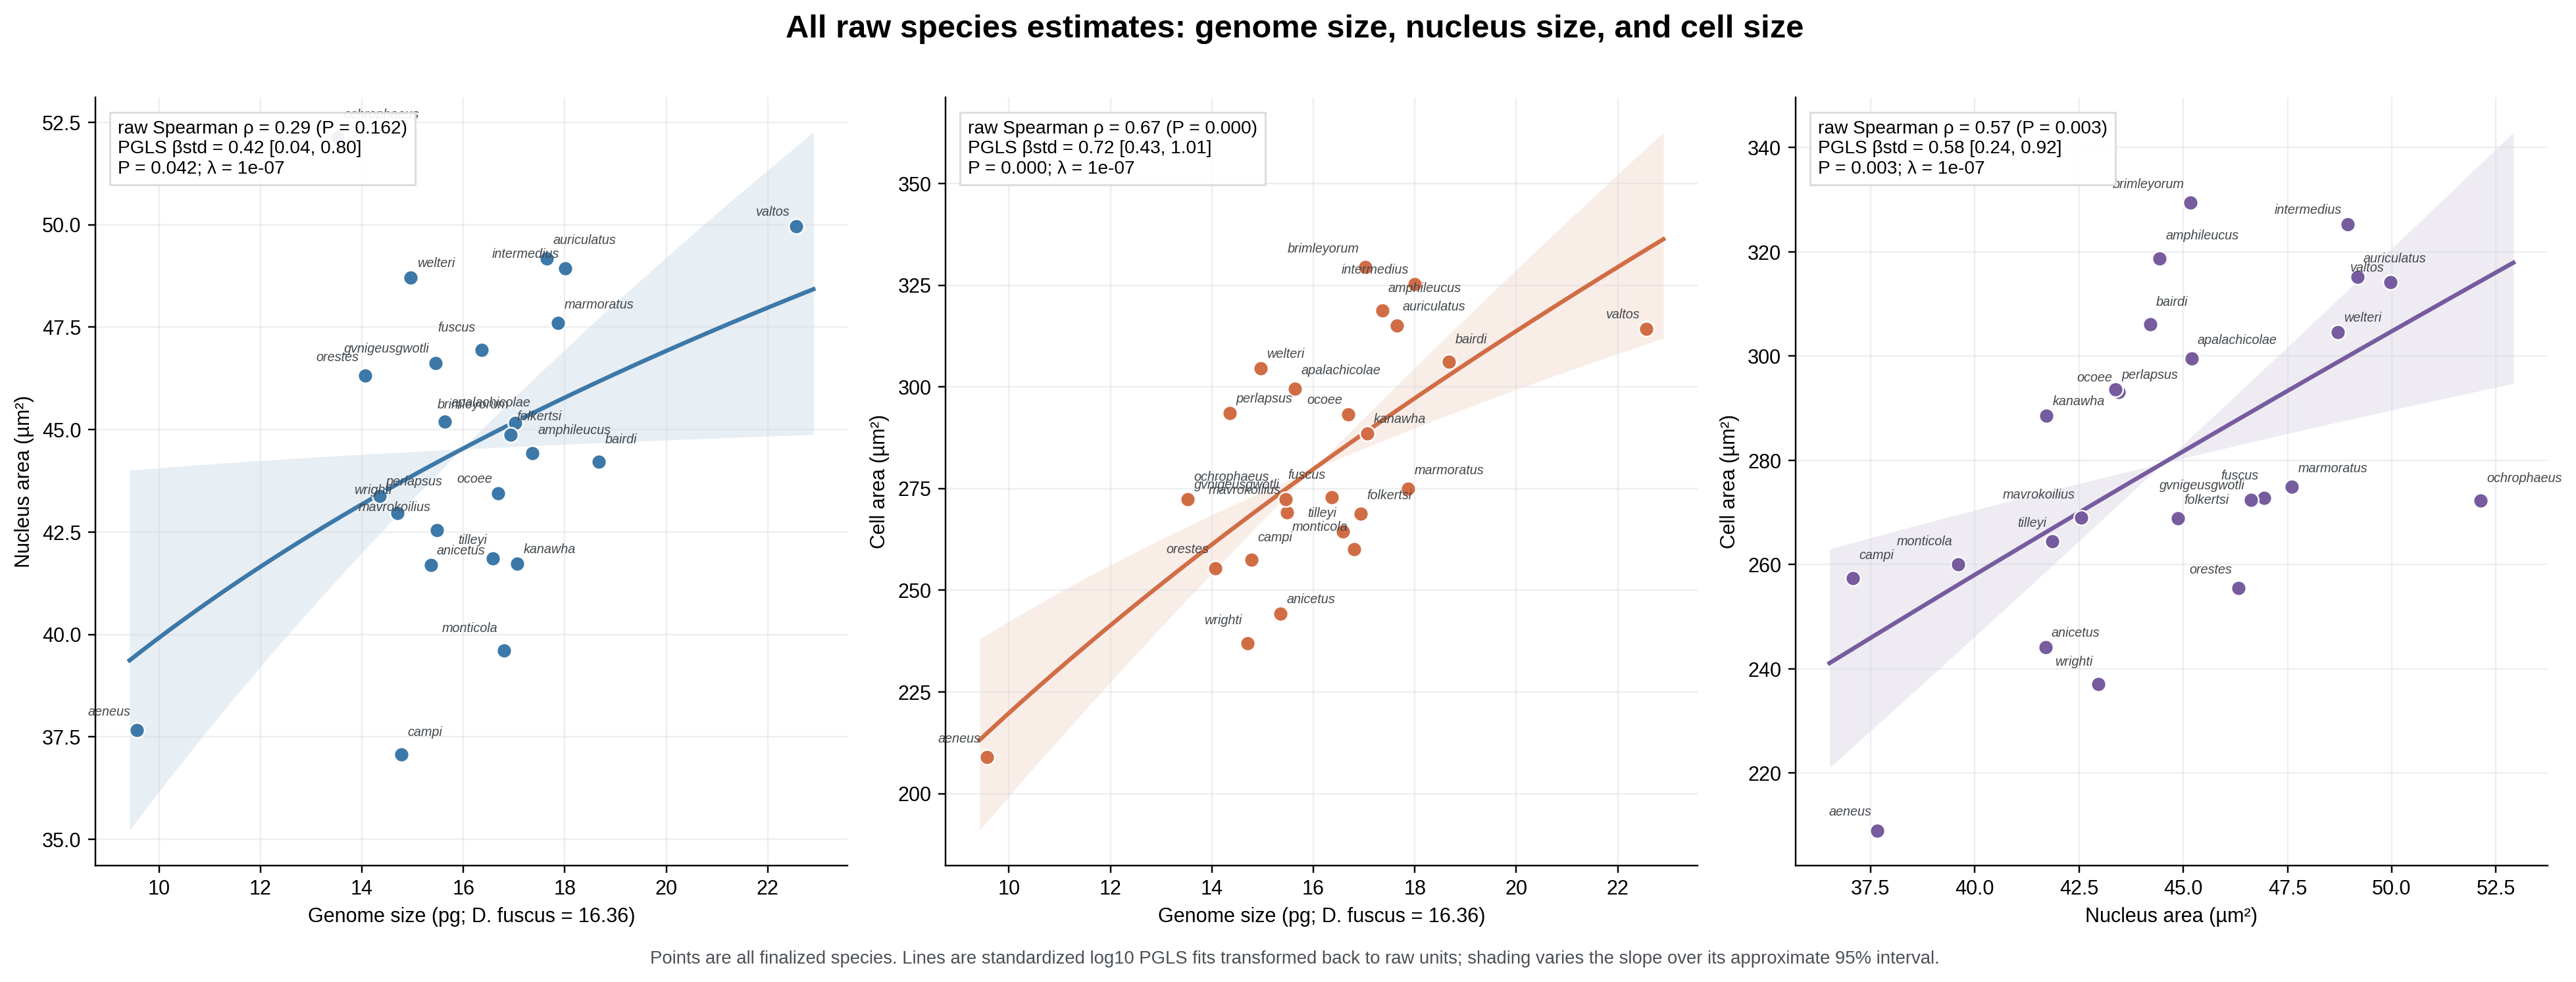

In [3]:
display(Image(filename=str(FIG_DIR / "01_raw_trait_relationships.png"), width=1450))


All three pairwise associations are positive. The path question is harder:
which association remains after conditioning on the third trait, and is that
conclusion stable after phylogenetic correction and measurement uncertainty?
Simple pairwise significance cannot orient a causal arrow.


In [4]:
display(pairwise[[
    "relation_id", "outcome", "predictor", "standardized_coefficient",
    "standard_error", "ci_low", "ci_high", "p_value",
    "fitted_phylogenetic_parameter", "r_squared", "n_species"
]].style.format({
    "standardized_coefficient": "{:.3f}", "standard_error": "{:.3f}",
    "ci_low": "{:.3f}", "ci_high": "{:.3f}", "p_value": "{:.4f}",
    "fitted_phylogenetic_parameter": "{:.2g}", "r_squared": "{:.3f}"
}))


,relation_id,outcome,predictor,standardized_coefficient,standard_error,ci_low,ci_high,p_value,fitted_phylogenetic_parameter,r_squared,n_species
0,genome_to_nucleus,nucleus_size,genome_size,0.419,0.194,0.040,0.798,0.0415,1e-07,0.176,24
1,nucleus_to_genome,genome_size,nucleus_size,0.289,0.175,-0.053,0.631,0.1116,1,0.111,24
2,genome_to_cell,cell_size,genome_size,0.717,0.149,0.425,1.008,0.0001,1e-07,0.514,24
3,cell_to_genome,genome_size,cell_size,0.717,0.149,0.425,1.008,0.0001,1e-07,0.514,24
4,nucleus_to_cell,cell_size,nucleus_size,0.579,0.174,0.239,0.920,0.0030,1e-07,0.336,24
5,cell_to_nucleus,nucleus_size,cell_size,0.579,0.174,0.239,0.920,0.0030,1e-07,0.336,24
6,genome_and_nucleus_to_cell,cell_size,genome_size,0.575,0.150,0.280,0.870,0.0010,1e-07,0.608,24
7,genome_and_nucleus_to_cell,cell_size,nucleus_size,0.338,0.150,0.044,0.633,0.0354,1e-07,0.608,24
8,genome_and_cell_to_nucleus,nucleus_size,genome_size,0.008,0.255,-0.492,0.508,0.9755,1e-07,0.336,24
9,genome_and_cell_to_nucleus,nucleus_size,cell_size,0.574,0.255,0.074,1.073,0.0354,1e-07,0.336,24


## 3. Method mirrored from the reference study


The workflow mirrors Yu et al. (2020): state candidate DAGs, derive their
d-separation claims, test those claims by phylogenetic generalized least
squares, combine component probabilities with Fisher's C, reject models with
global P < 0.05, and rank the surviving structures with small-sample CICc.
Models at ΔCICc ≤ 2 are treated as competitive.

Primary sources: [Yu et al. reference paper](https://doi.org/10.1111/jzo.12755),
[phylopath method paper](https://doi.org/10.7717/peerj.4718), and
[original phylogenetic confirmatory path framework](https://doi.org/10.1111/j.1558-5646.2012.01790.x).

With only three variables there are 25 labeled DAGs but 11
Markov-equivalence classes. Ten have testable independence claims. Six fully
connected DAGs collapse into one saturated class with no d-separation claim,
so `phylopath` cannot score that class. Because this analysis exhaustively
screens every distinguishable class rather than testing a small preregistered
model set, it is an **exploratory structural screen**, not confirmatory proof
of causality.

The displayed gallery is intentionally narrower than that exhaustive fitted
universe: it omits the biologically implausible genome-cell-only skeleton and
the untestable saturated class, and it explicitly shows both genome ->
nucleus -> cell and cell -> nucleus -> genome.


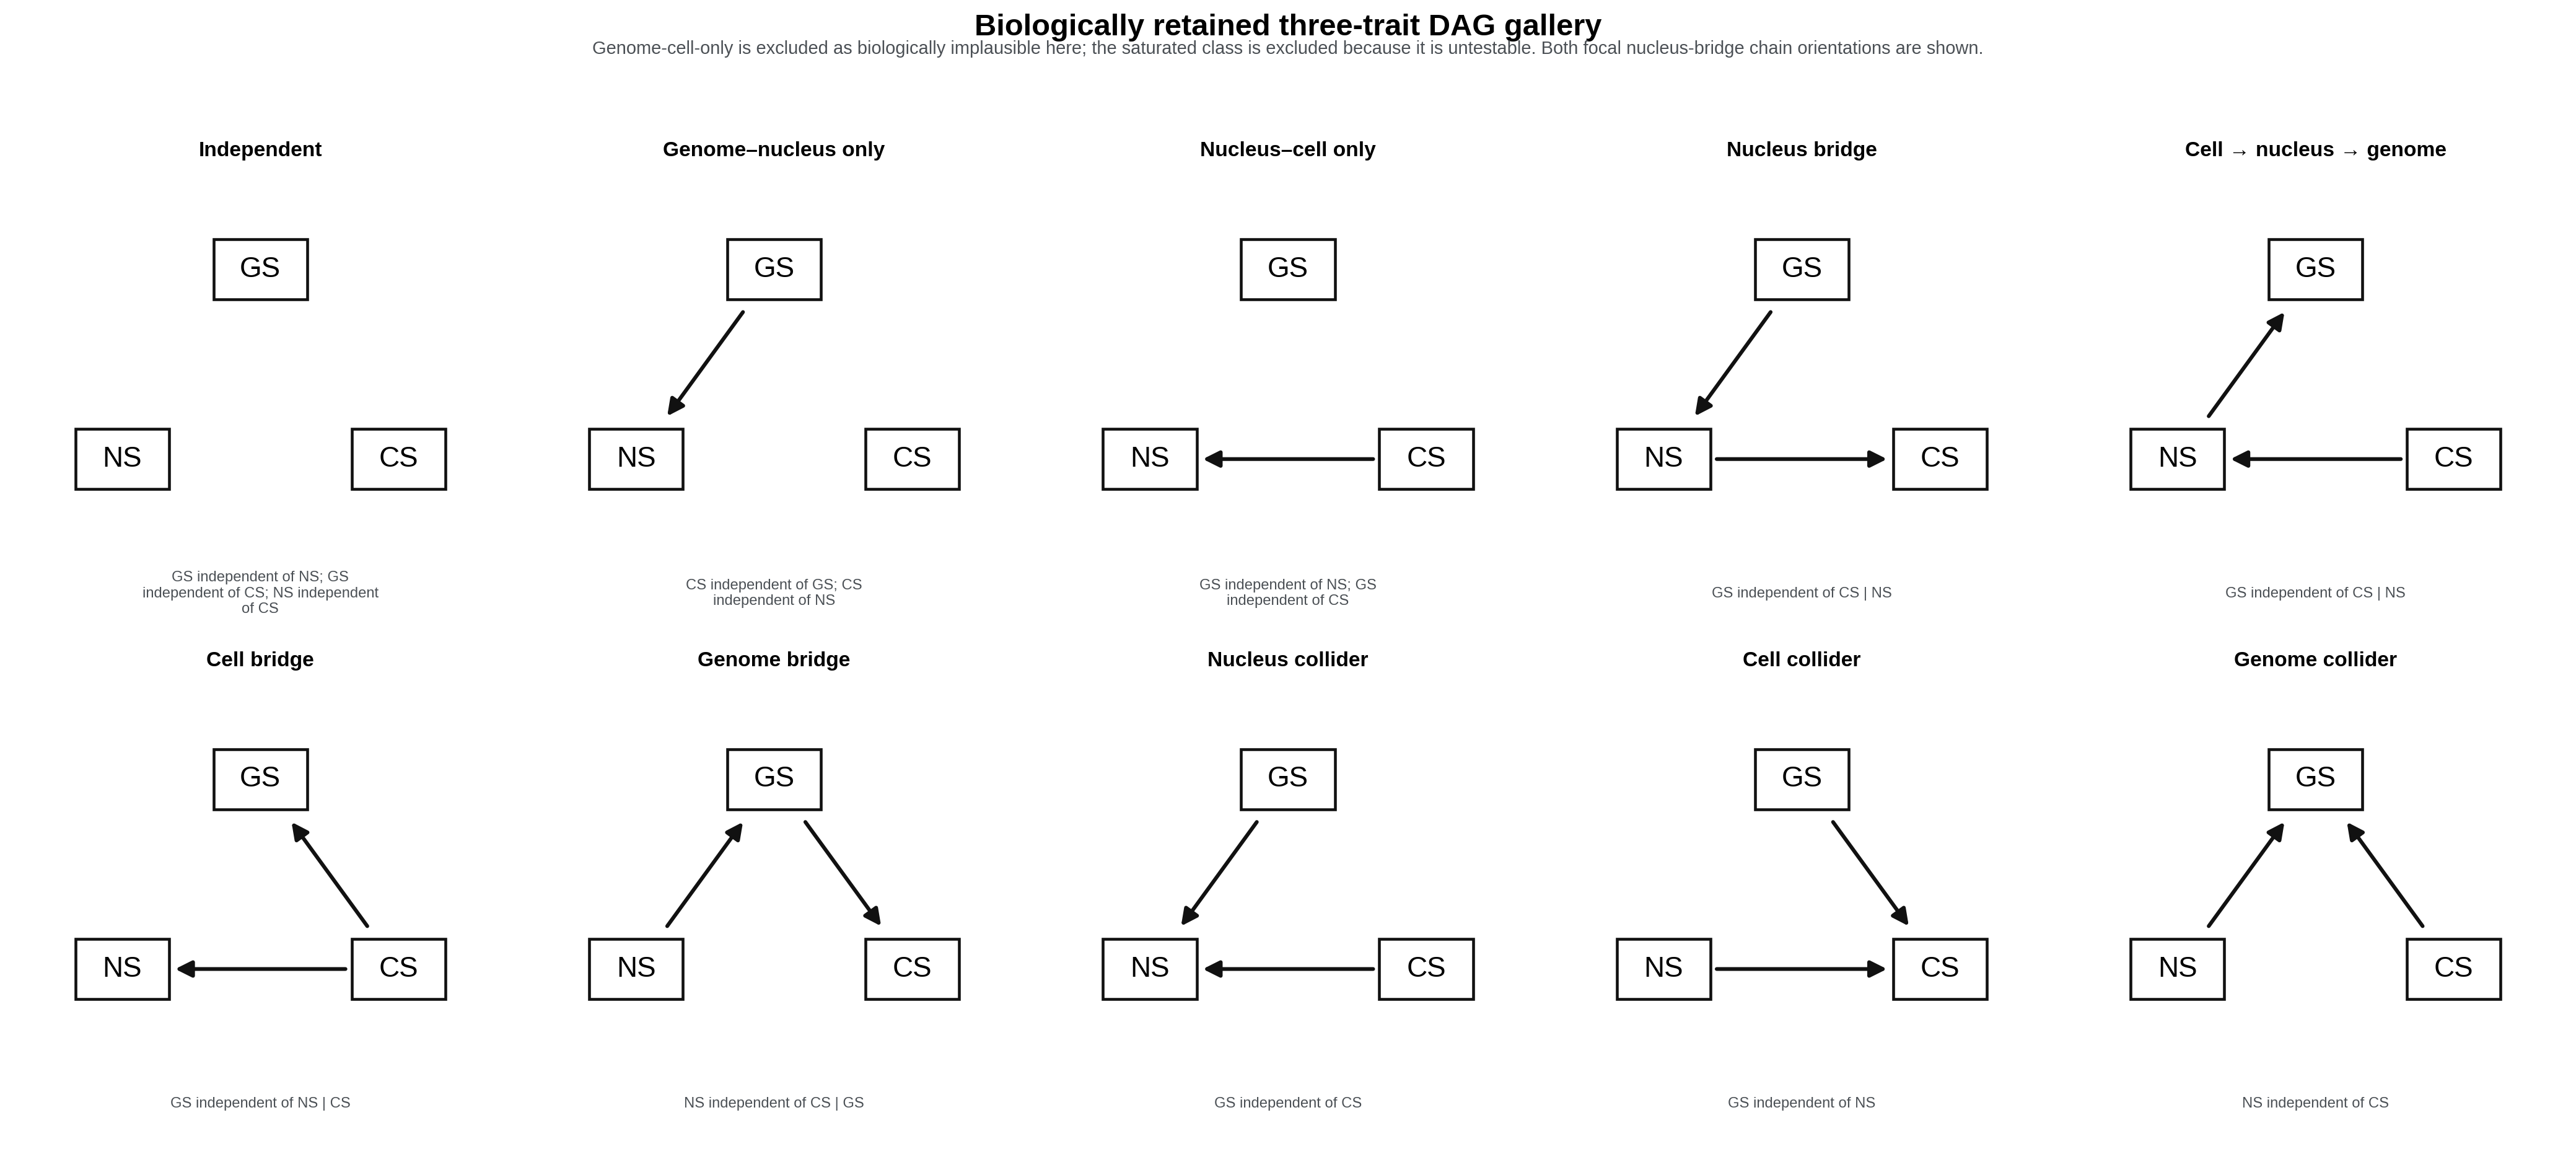

,equivalence_class,basis_claim,testable_by_dsep,n_labeled_dags,min_edges
6,independent,genome_size _||_ nucleus_size; genome_size _||...,True,1,0
3,genome_cell_only,nucleus_size _||_ genome_size; nucleus_size _|...,True,2,1
5,genome_nucleus_only,cell_size _||_ genome_size; cell_size _||_ nuc...,True,2,1
8,nucleus_cell_only,genome_size _||_ nucleus_size; genome_size _||...,True,2,1
0,cell_bridge,genome_size _||_ nucleus_size | cell_size,True,3,2
1,cell_collider,genome_size _||_ nucleus_size,True,1,2
2,genome_bridge,nucleus_size _||_ cell_size | genome_size,True,3,2
4,genome_collider,nucleus_size _||_ cell_size,True,1,2
7,nucleus_bridge,genome_size _||_ cell_size | nucleus_size,True,3,2
9,nucleus_collider,genome_size _||_ cell_size,True,1,2


In [5]:
display(Image(filename=str(FIG_DIR / "04_candidate_equivalence_class_gallery.png"), width=1300))
class_summary = (
    dags.groupby(["equivalence_class", "basis_claim", "testable_by_dsep"], dropna=False)
    .agg(n_labeled_dags=("dag_id", "size"), min_edges=("n_edges", "min"))
    .reset_index()
    .sort_values(["min_edges", "equivalence_class"])
)
display(class_summary)


## 4. Primary model comparison


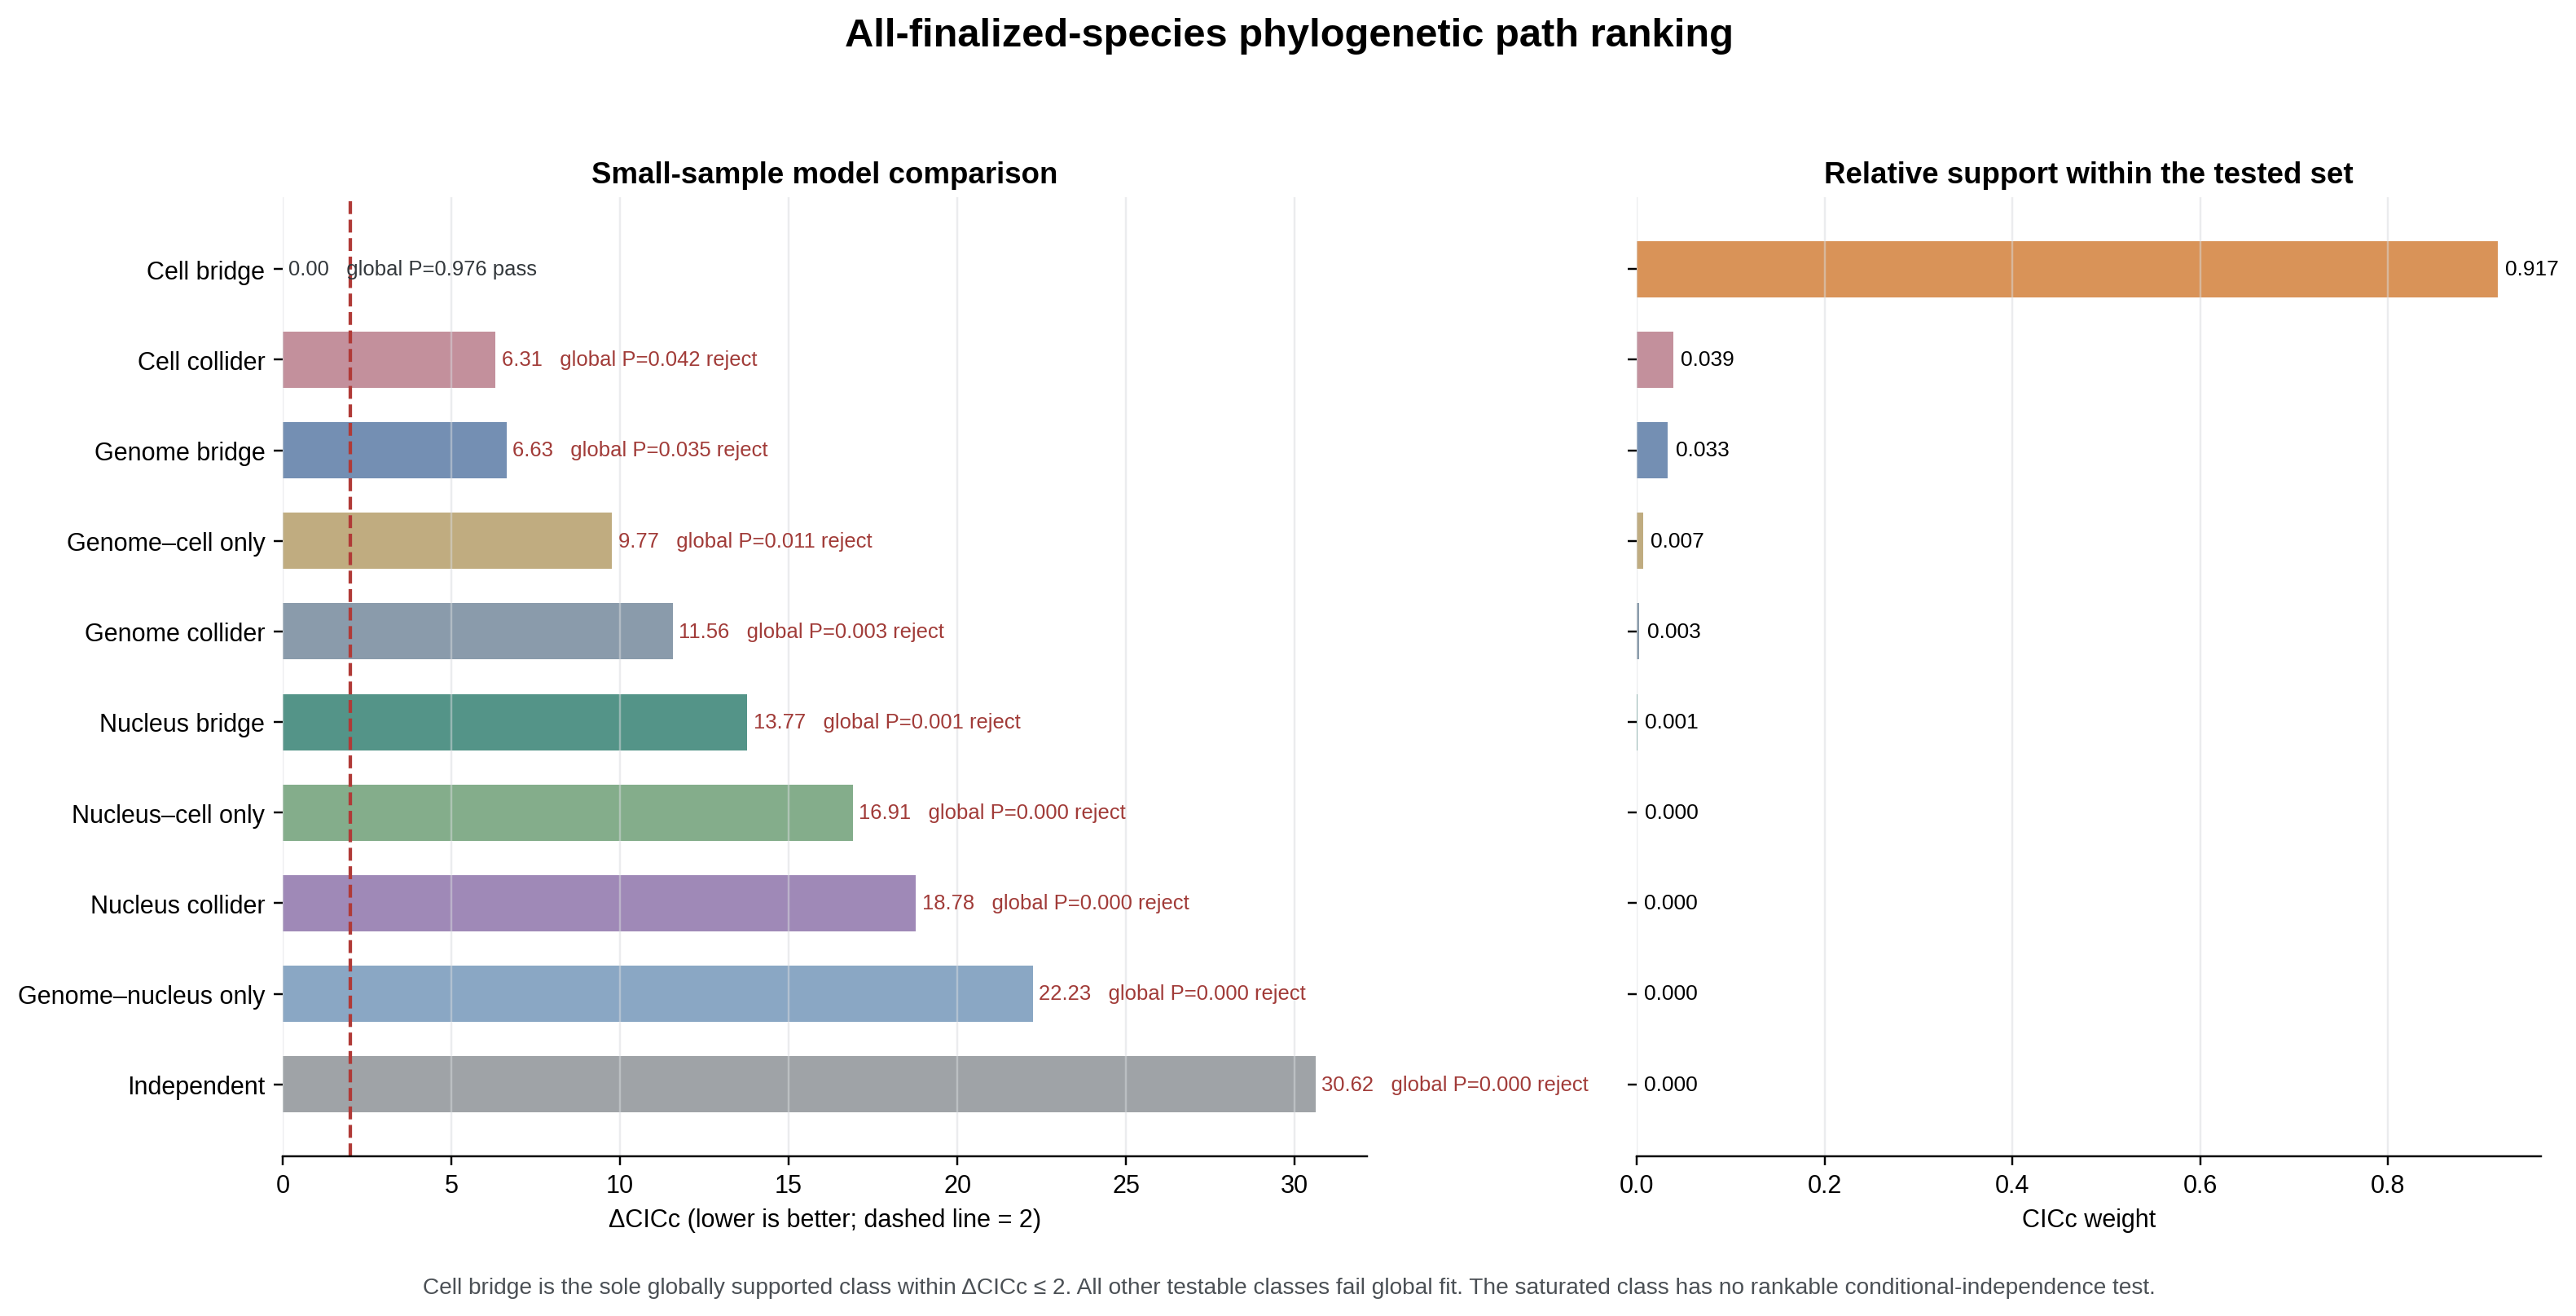

,rank,model,k,q,C,p,CICc,delta_CICc,w,globally_supported,admissible_competitive
0,1,cell_bridge,1,5,0.050,0.9755,13.383,0.000,0.917,True,True
1,2,cell_collider,1,5,6.362,0.0415,19.695,6.312,0.039,False,False
2,3,genome_bridge,1,5,6.684,0.0354,20.018,6.635,0.033,False,False
3,4,genome_cell_only,2,4,13.046,0.0111,23.152,9.769,0.007,False,False
4,5,genome_collider,1,5,11.610,0.0030,24.943,11.560,0.003,False,False
5,6,nucleus_bridge,1,5,13.821,0.0010,27.155,13.772,0.001,False,False
6,7,nucleus_cell_only,2,4,20.183,0.0005,30.289,16.906,0.000,False,False
7,8,nucleus_collider,1,5,18.828,0.0001,32.161,18.779,0.000,False,False
8,9,genome_nucleus_only,2,4,25.513,0.0000,35.618,22.235,0.000,False,False
9,10,independent,3,3,36.800,0.0000,44.000,30.617,0.000,False,False


In [6]:
display(Image(filename=str(FIG_DIR / "02_primary_model_ranking.png"), width=1250))
display(primary[[
    "rank", "model", "k", "q", "C", "p", "CICc", "delta_CICc", "w",
    "globally_supported", "admissible_competitive"
]].style.format({
    "C": "{:.3f}", "p": "{:.4f}", "CICc": "{:.3f}",
    "delta_CICc": "{:.3f}", "w": "{:.3f}"
}))


The point estimate favors Cell bridge. Cell collider is ΔCICc =
6.31 behind and is not competitive at the prespecified delta CICc <= 2 threshold.
The nucleus–cell-only
model is globally non-rejected but falls outside ΔCICc ≤ 2. The independence,
collider, and genome-bridge structures are rejected or weakly supported.

The decisive d-separation tests are symmetric in their warning:

- **Nucleus bridge:** does genome still explain cell after nucleus is in the
  model? P = 0.001.
- **Cell bridge:** does genome still explain nucleus after cell is in the
  model? P = 0.976.

Non-significance means those structures are *not rejected*; it does not prove
the corresponding independence relation. All six primary lambda component
fits reached the lambda boundary (approximately zero), so the BM and OU
sensitivity rows are part of the result rather than an optional appendix.


In [7]:
display(dsep[[
    "candidate_model", "independence_claim", "component_p",
    "fitted_phylogenetic_parameter"
]].style.format({"component_p": "{:.4f}", "fitted_phylogenetic_parameter": "{:.2g}"}))
display(fit_warnings)


,candidate_model,independence_claim,component_p,fitted_phylogenetic_parameter
0,independent,n ~ g,0.0415,1e-07
1,independent,c ~ n,0.0030,1e-07
2,independent,c ~ g,0.0001,1e-07
3,genome_nucleus_only,c ~ g,0.0001,1e-07
4,genome_nucleus_only,c ~ g + n,0.0354,1e-07
5,nucleus_cell_only,n ~ g,0.0415,1e-07
6,nucleus_cell_only,c ~ n + g,0.0010,1e-07
7,genome_cell_only,n ~ g,0.0415,1e-07
8,genome_cell_only,c ~ g + n,0.0354,1e-07
9,nucleus_bridge,c ~ n + g,0.0010,1e-07


,analysis_type,replicate_id,tree_id,evolutionary_model,warning_source,warning
0,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n n ~ g \nprod...
1,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n c ~ n \nprod...
2,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n c ~ g \nprod...
3,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n c ~ g + n \n...
4,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n c ~ n + g \n...
5,primary,point_estimate,focal_primary,lambda,phylopath_stored,Fitting the following model:\n n ~ c + g \n...
6,primary,point_estimate,focal_primary,lambda,runtime,Some models produced warnings. Use `show_warni...


## 5. The three proposed causal stories


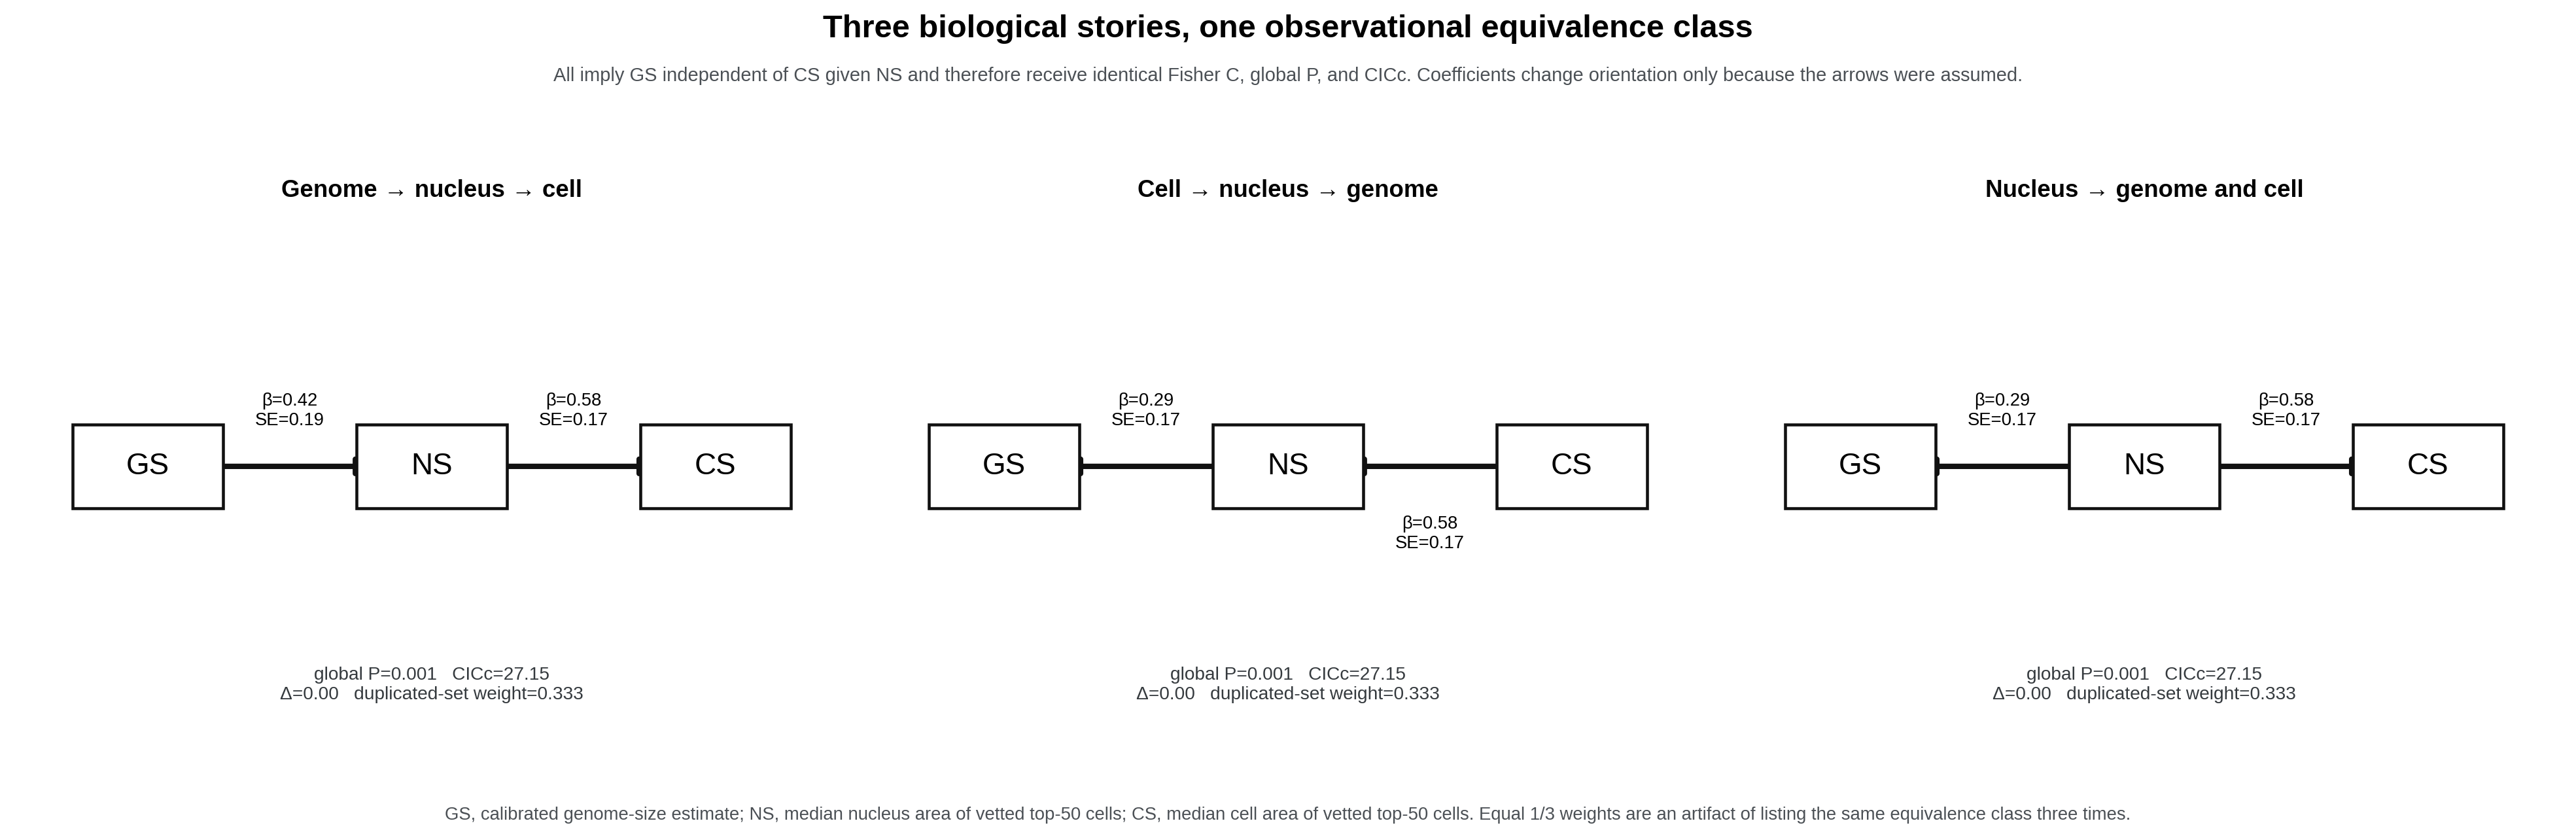

,model,C,p,CICc,delta_CICc,w
0,genome_to_nucleus_to_cell,13.821299,0.000997,27.154632,0,0.333333
1,cell_to_nucleus_to_genome,13.821299,0.000997,27.154632,0,0.333333
2,nucleus_to_genome_and_cell,13.821299,0.000997,27.154632,0,0.333333


,mechanism,equivalence_class,parent,child,standardized_coefficient,standard_error,ci_low,ci_high,interval_excludes_zero
0,genome_to_nucleus_to_cell,nucleus_bridge,genome_size,nucleus_size,0.419018,0.193582,0.039599,0.798438,True
1,genome_to_nucleus_to_cell,nucleus_bridge,nucleus_size,cell_size,0.579301,0.173783,0.238687,0.919916,True
2,cell_to_nucleus_to_genome,nucleus_bridge,cell_size,nucleus_size,0.579301,0.173783,0.238687,0.919916,True
3,cell_to_nucleus_to_genome,nucleus_bridge,nucleus_size,genome_size,0.289345,0.174566,-0.052805,0.631495,False
4,nucleus_to_genome_and_cell,nucleus_bridge,nucleus_size,cell_size,0.579301,0.173783,0.238687,0.919916,True
5,nucleus_to_genome_and_cell,nucleus_bridge,nucleus_size,genome_size,0.289345,0.174566,-0.052805,0.631495,False


In [8]:
display(Image(filename=str(FIG_DIR / "03_markov_equivalent_user_mechanisms.png"), width=1450))
display(mechanisms[["model", "C", "p", "CICc", "delta_CICc", "w"]])
display(mechanism_edges)


<div class="warning">
<b>Hard identifiability limit.</b> Genome → nucleus → cell, cell → nucleus →
genome, and nucleus → both genome and cell have the same skeleton, no
collider, and the same testable statement: genome and cell are independent
conditional on nucleus. They therefore receive exactly the same Fisher C,
global P, and CICc. No amount of refitting these same cross-sectional traits
can choose among the three directions.
</div>

The displayed coefficients are valid standardized associations under each
assumed arrow orientation. They are not evidence that one orientation caused
the others.


## 6. Ruthless stability tests


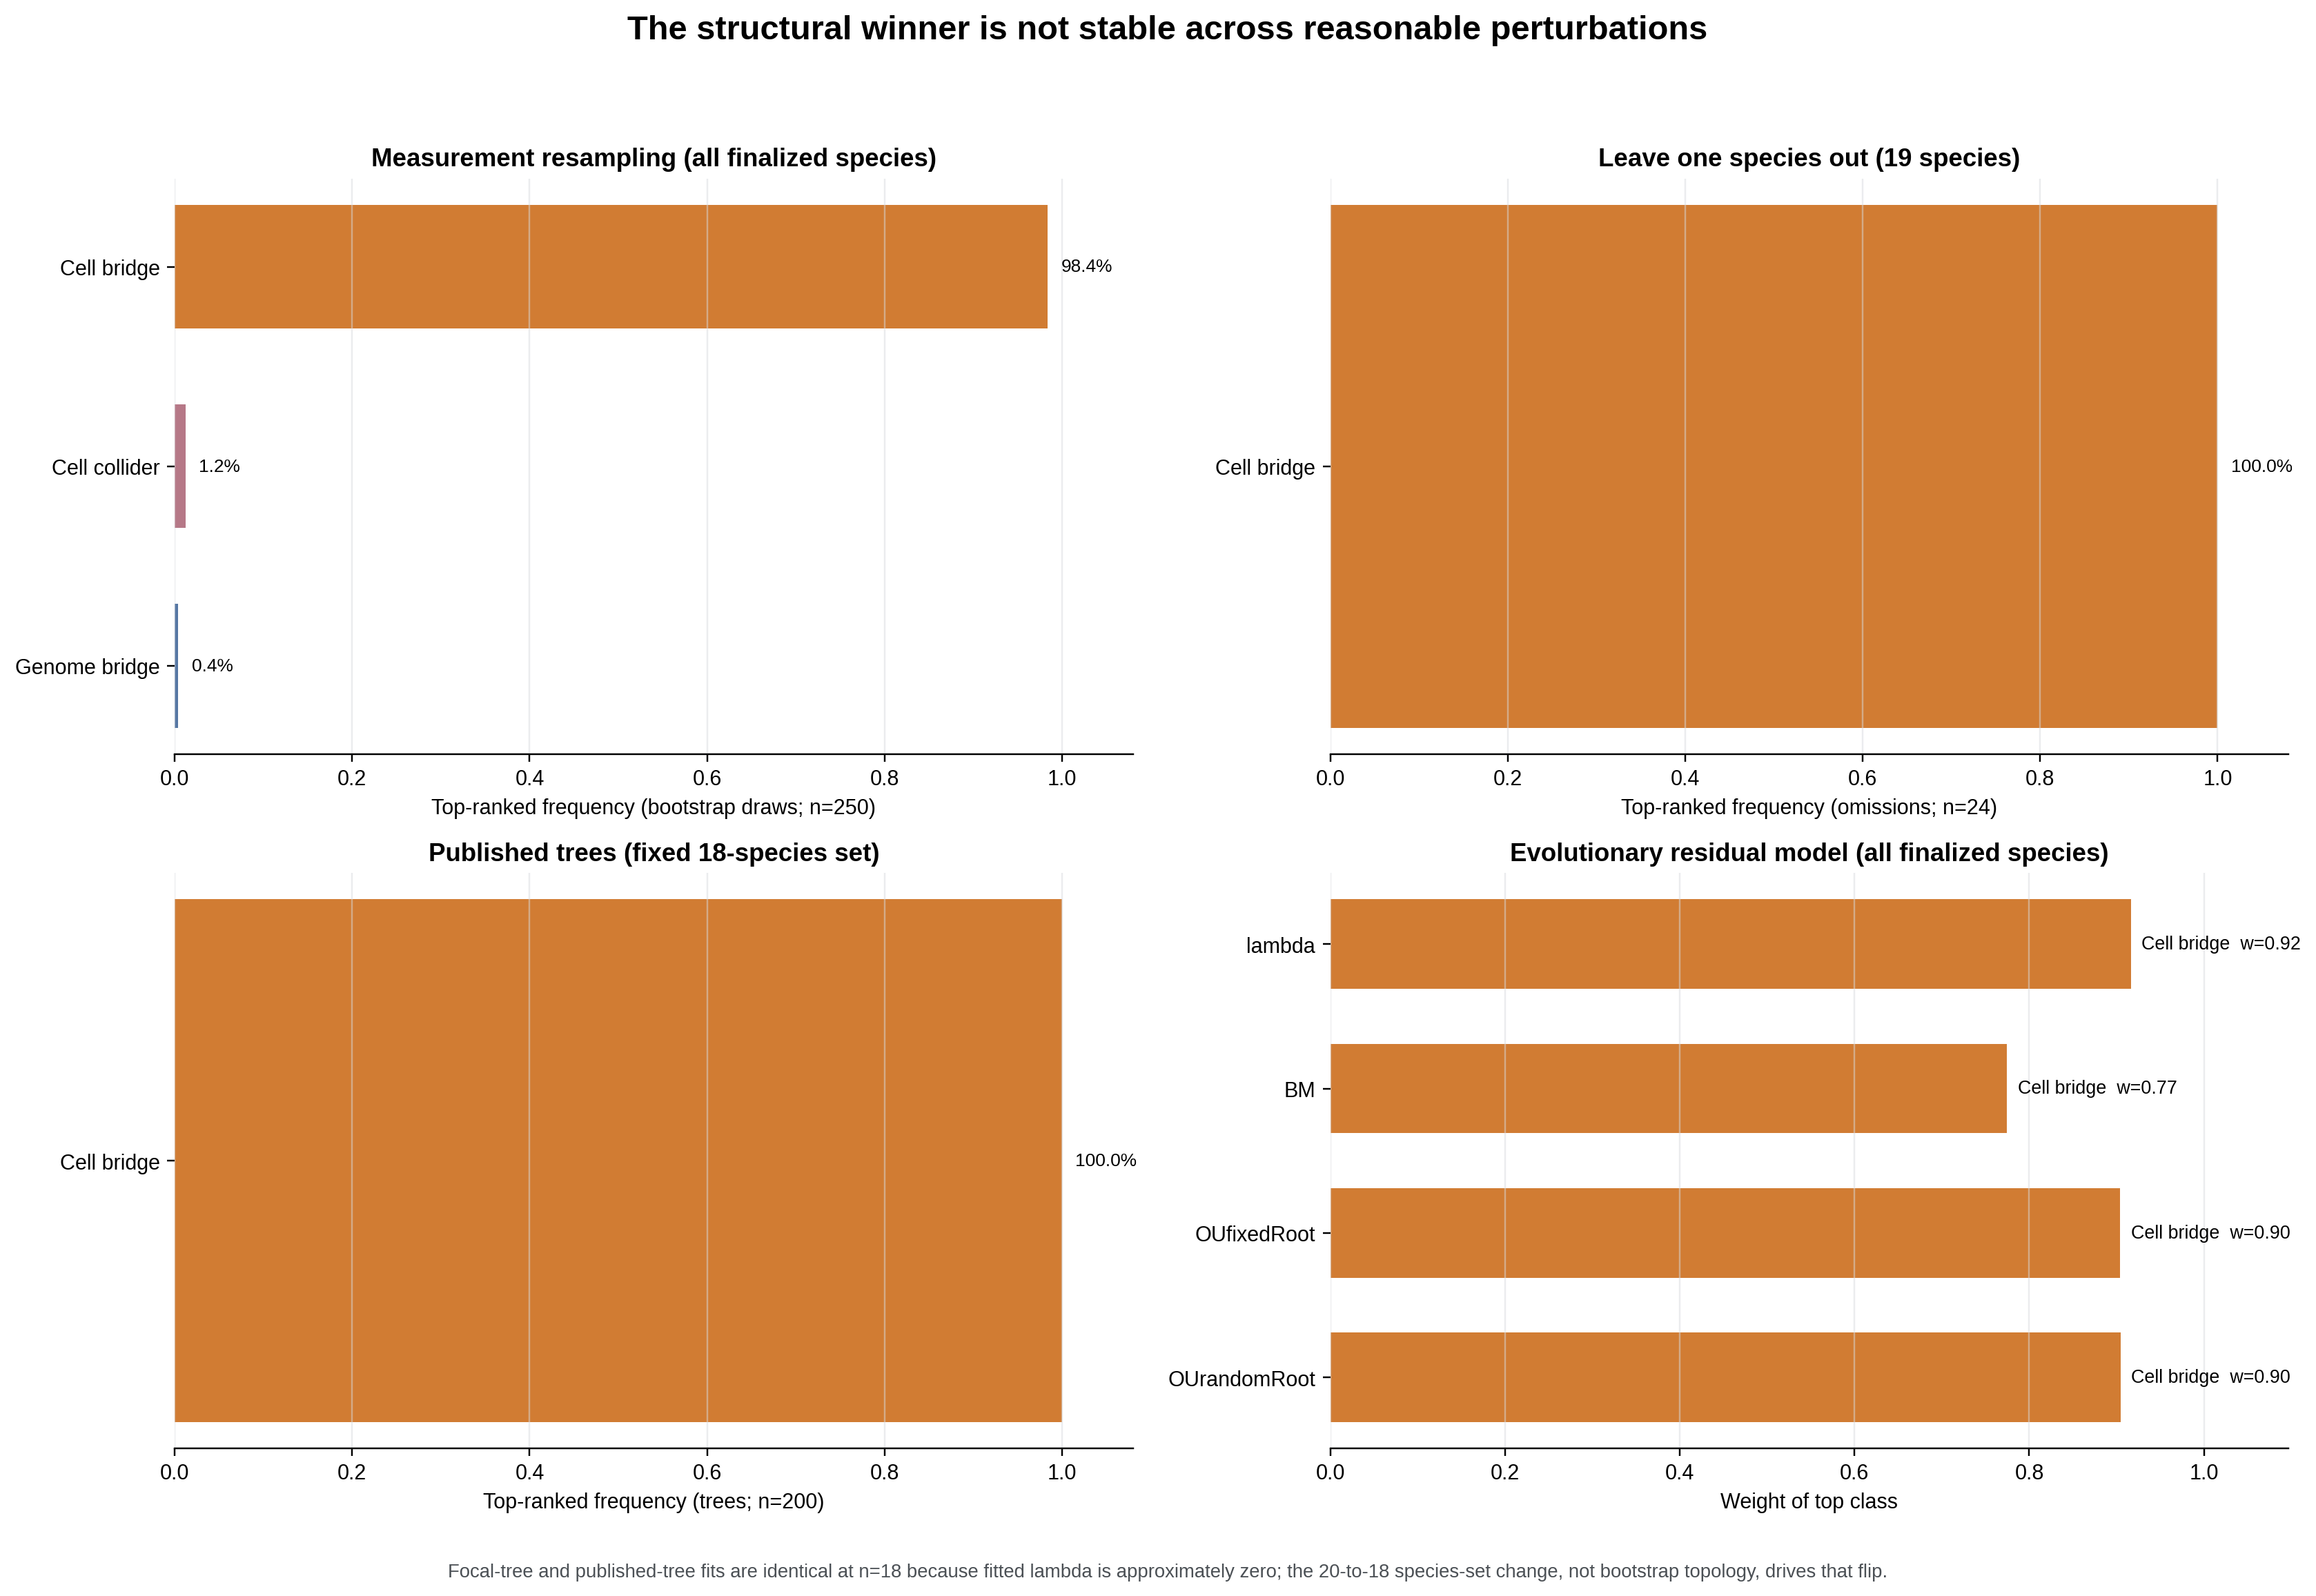

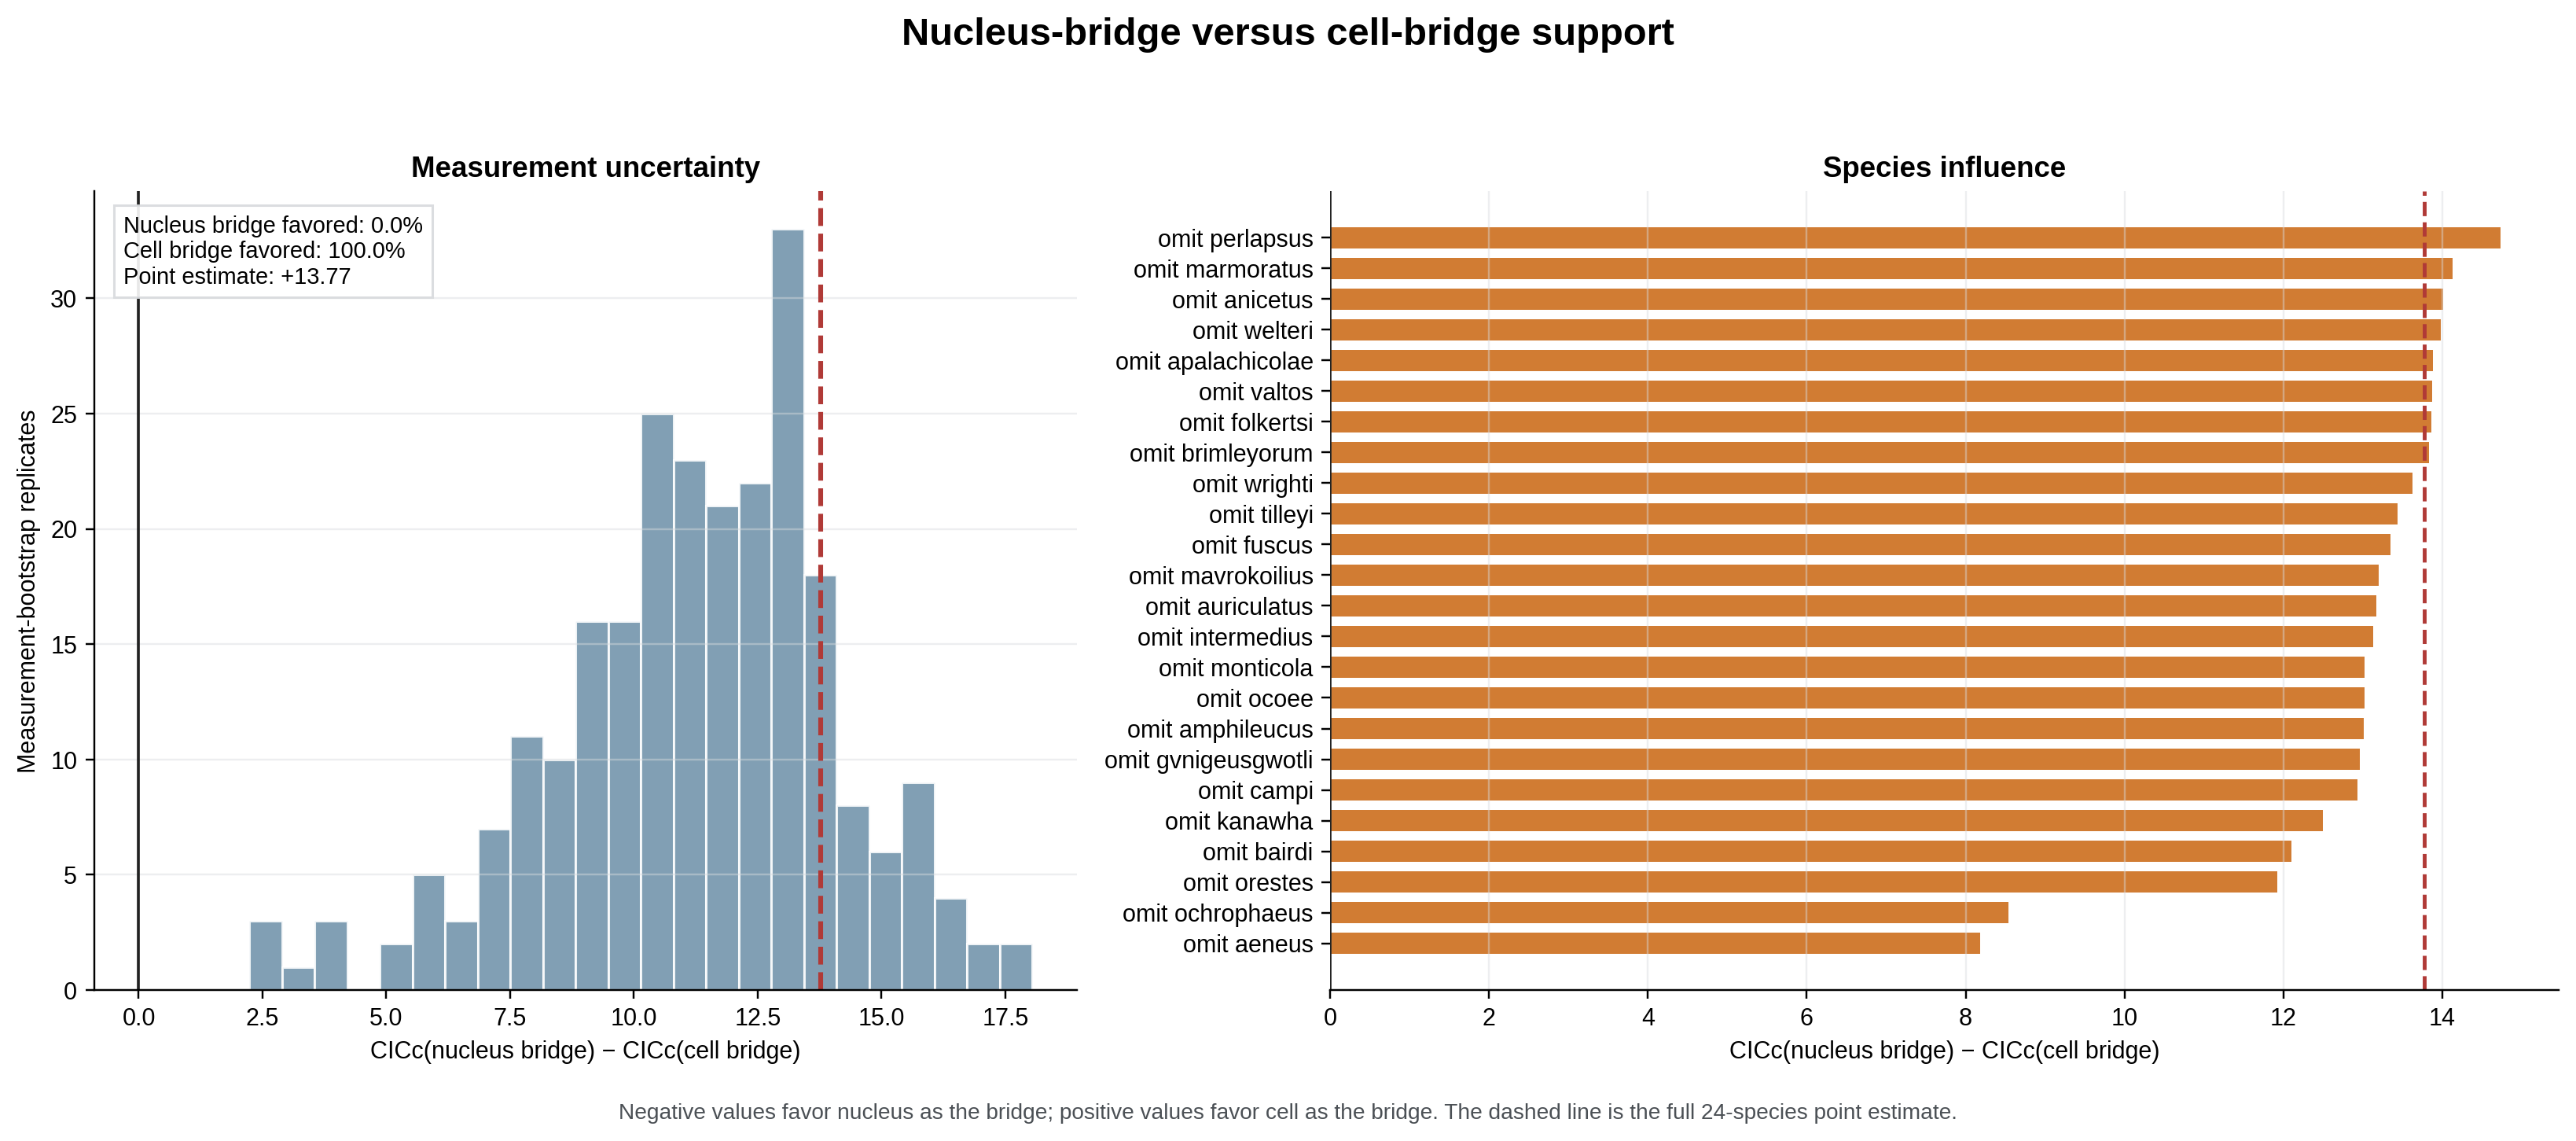

In [9]:
display(Image(filename=str(FIG_DIR / "05_model_stability.png"), width=1300))
display(Image(filename=str(FIG_DIR / "06_nucleus_vs_cell_bridge_contrast.png"), width=1300))


The structural label is fragile:

- Across 250 paired measurement-bootstrap draws, nucleus bridge ranks first
  0.0% of the time and cell bridge 98.4%.
- Across the 24 leave-one-species-out fits, the rates are
  0.0% and 100.0%, respectively.
- In the 18-species published-tree bootstrap panel: Cell bridge 200/200.
- Evolutionary-model winners are: lambda: Cell bridge, BM: Cell bridge, OUfixedRoot: Cell bridge, OUrandomRoot: Cell bridge.

The focal and published trees give identical rankings on the same 18 species,
and all 200 published bootstrap trees agree because fitted lambda is near
zero. The 18-species flip is therefore driven by dropping `D. brimleyorum`
and `D. folkertsi`, not by alternative bootstrap topologies.

This is not a technical footnote: the answer to “which trait is the bridge?”
changes under reasonable versions of the same analysis.


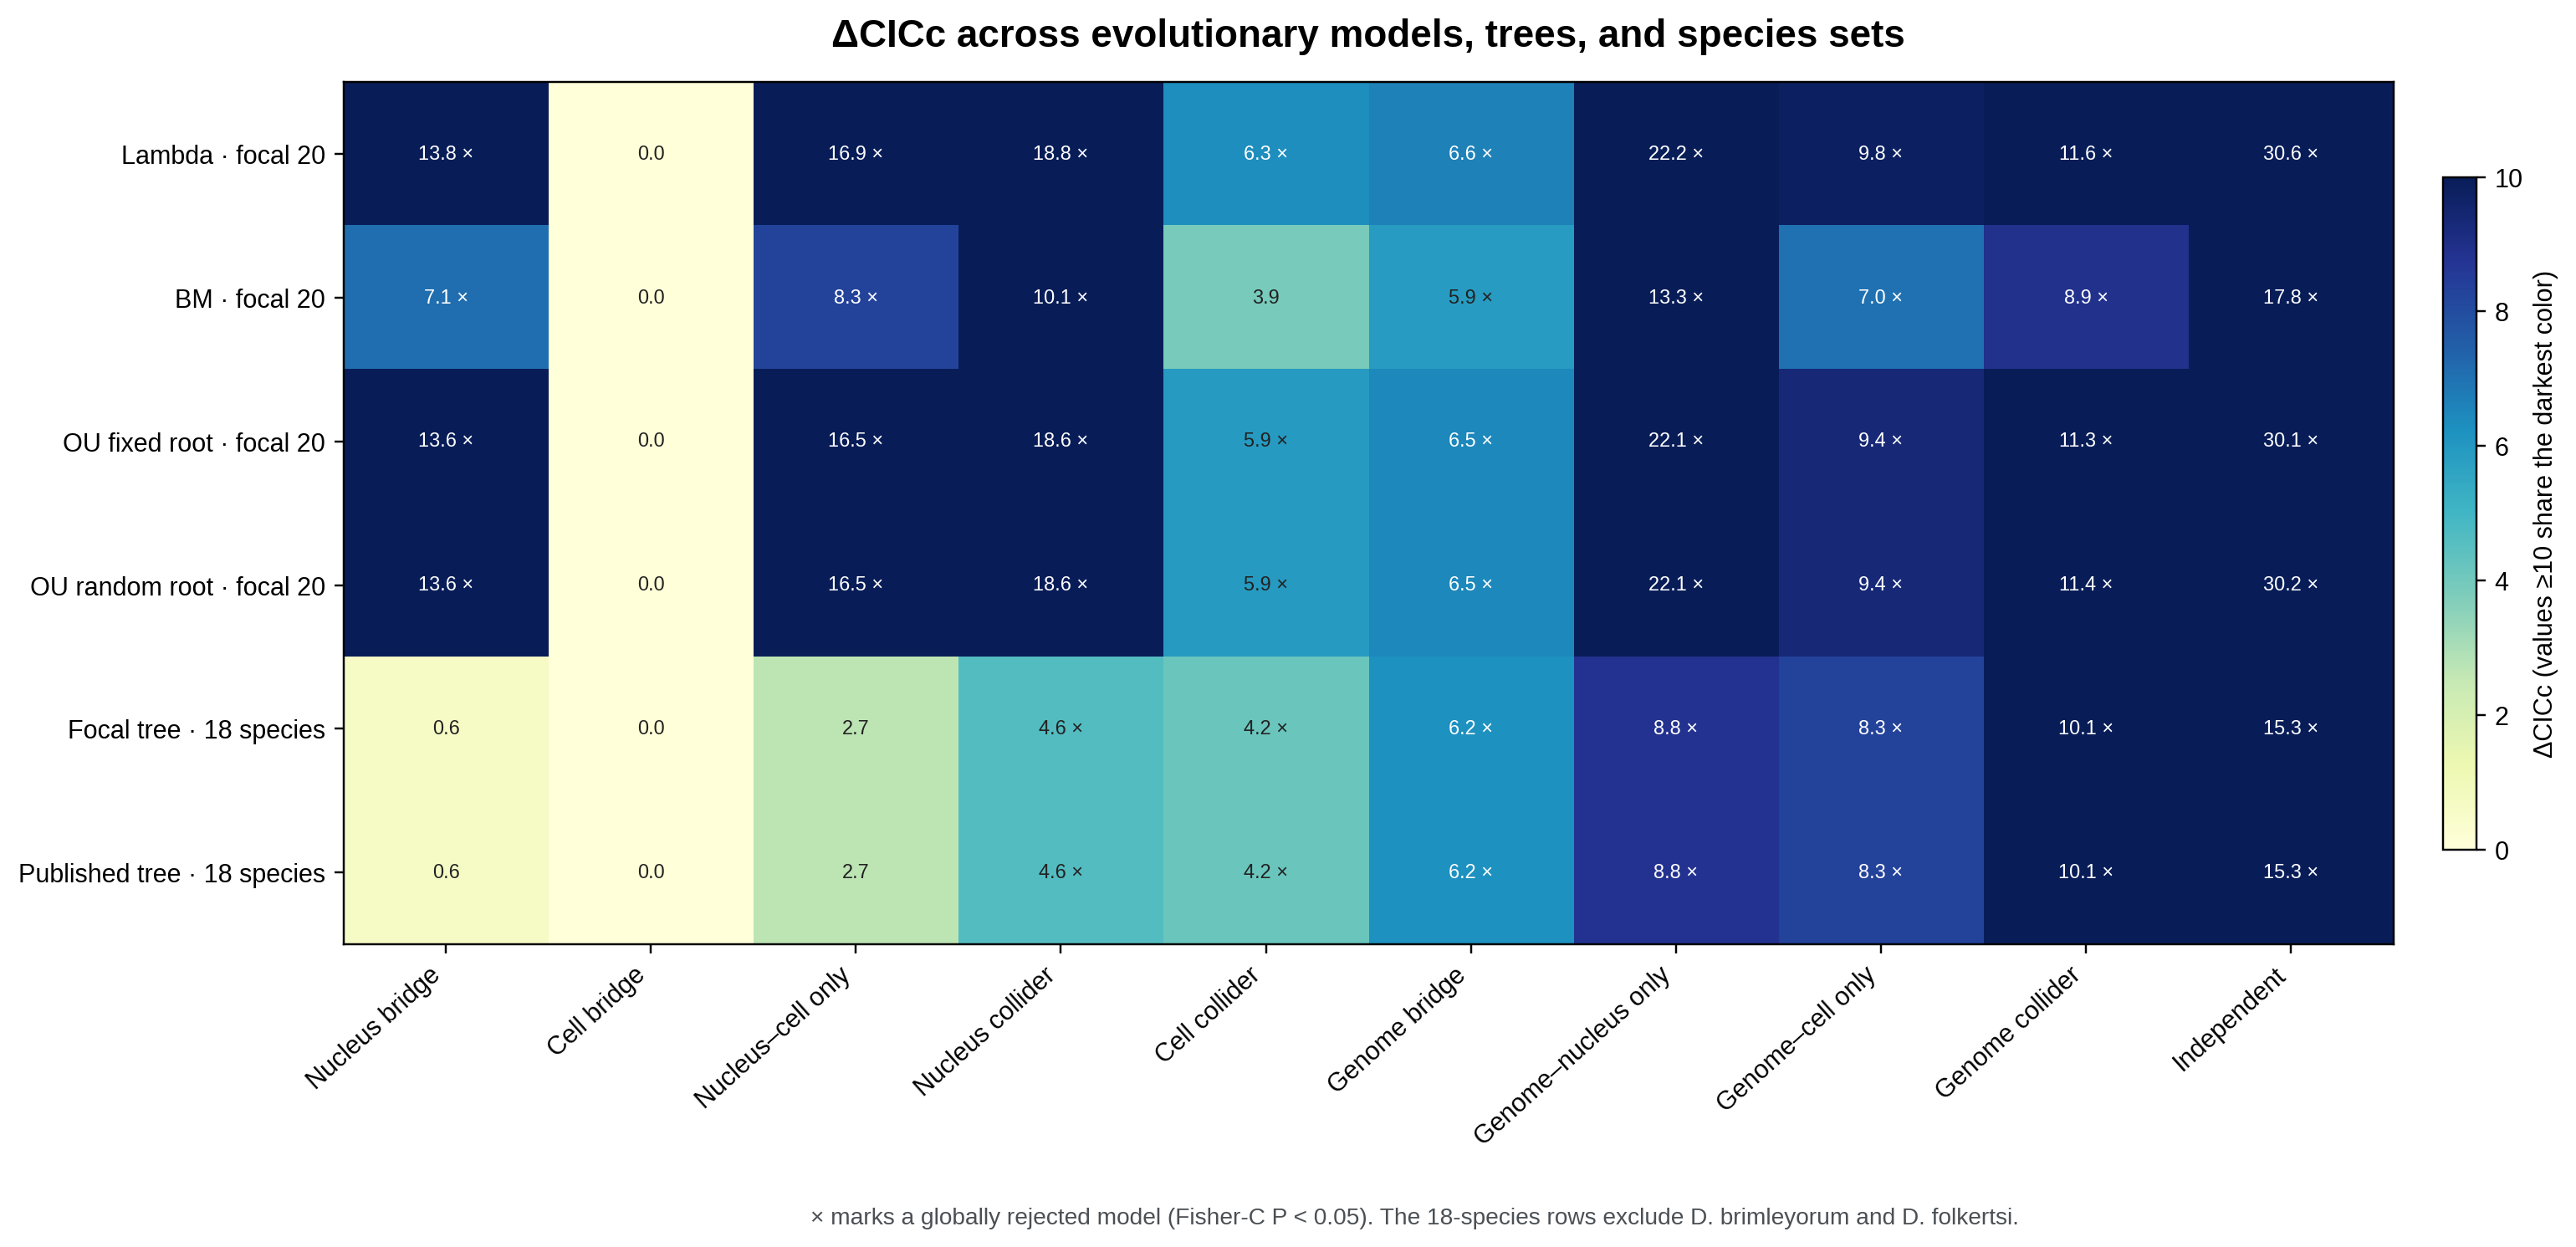

,tree_id,n_species,rank,model,p,delta_CICc,w
0,focal_primary,24,1,cell_bridge,0.975510,0.000000,0.916742
1,focal_primary,24,2,cell_collider,0.041544,6.312424,0.039041
2,focal_primary,24,3,genome_bridge,0.035358,6.634851,0.033228
10,focal_tree_18,18,1,cell_bridge,0.397238,0.000000,0.433567
11,focal_tree_18,18,2,nucleus_bridge,0.295383,0.592523,0.322397
12,focal_tree_18,18,3,nucleus_cell_only,0.076305,2.684109,0.113295
20,published_main_18,18,1,cell_bridge,0.397238,0.000000,0.433567
21,published_main_18,18,2,nucleus_bridge,0.295383,0.592523,0.322397
22,published_main_18,18,3,nucleus_cell_only,0.076305,2.684109,0.113295


In [10]:
display(Image(filename=str(FIG_DIR / "07_structural_sensitivity_heatmap.png"), width=1350))
point_tree_rows = trees.loc[
    trees.analysis_type.eq("tree_species_set_sensitivity")
    & trees["rank"].le(3),
    ["tree_id", "n_species", "rank", "model", "p", "delta_CICc", "w"]
]
display(point_tree_rows)


## 7. Small-sample simulation calibration


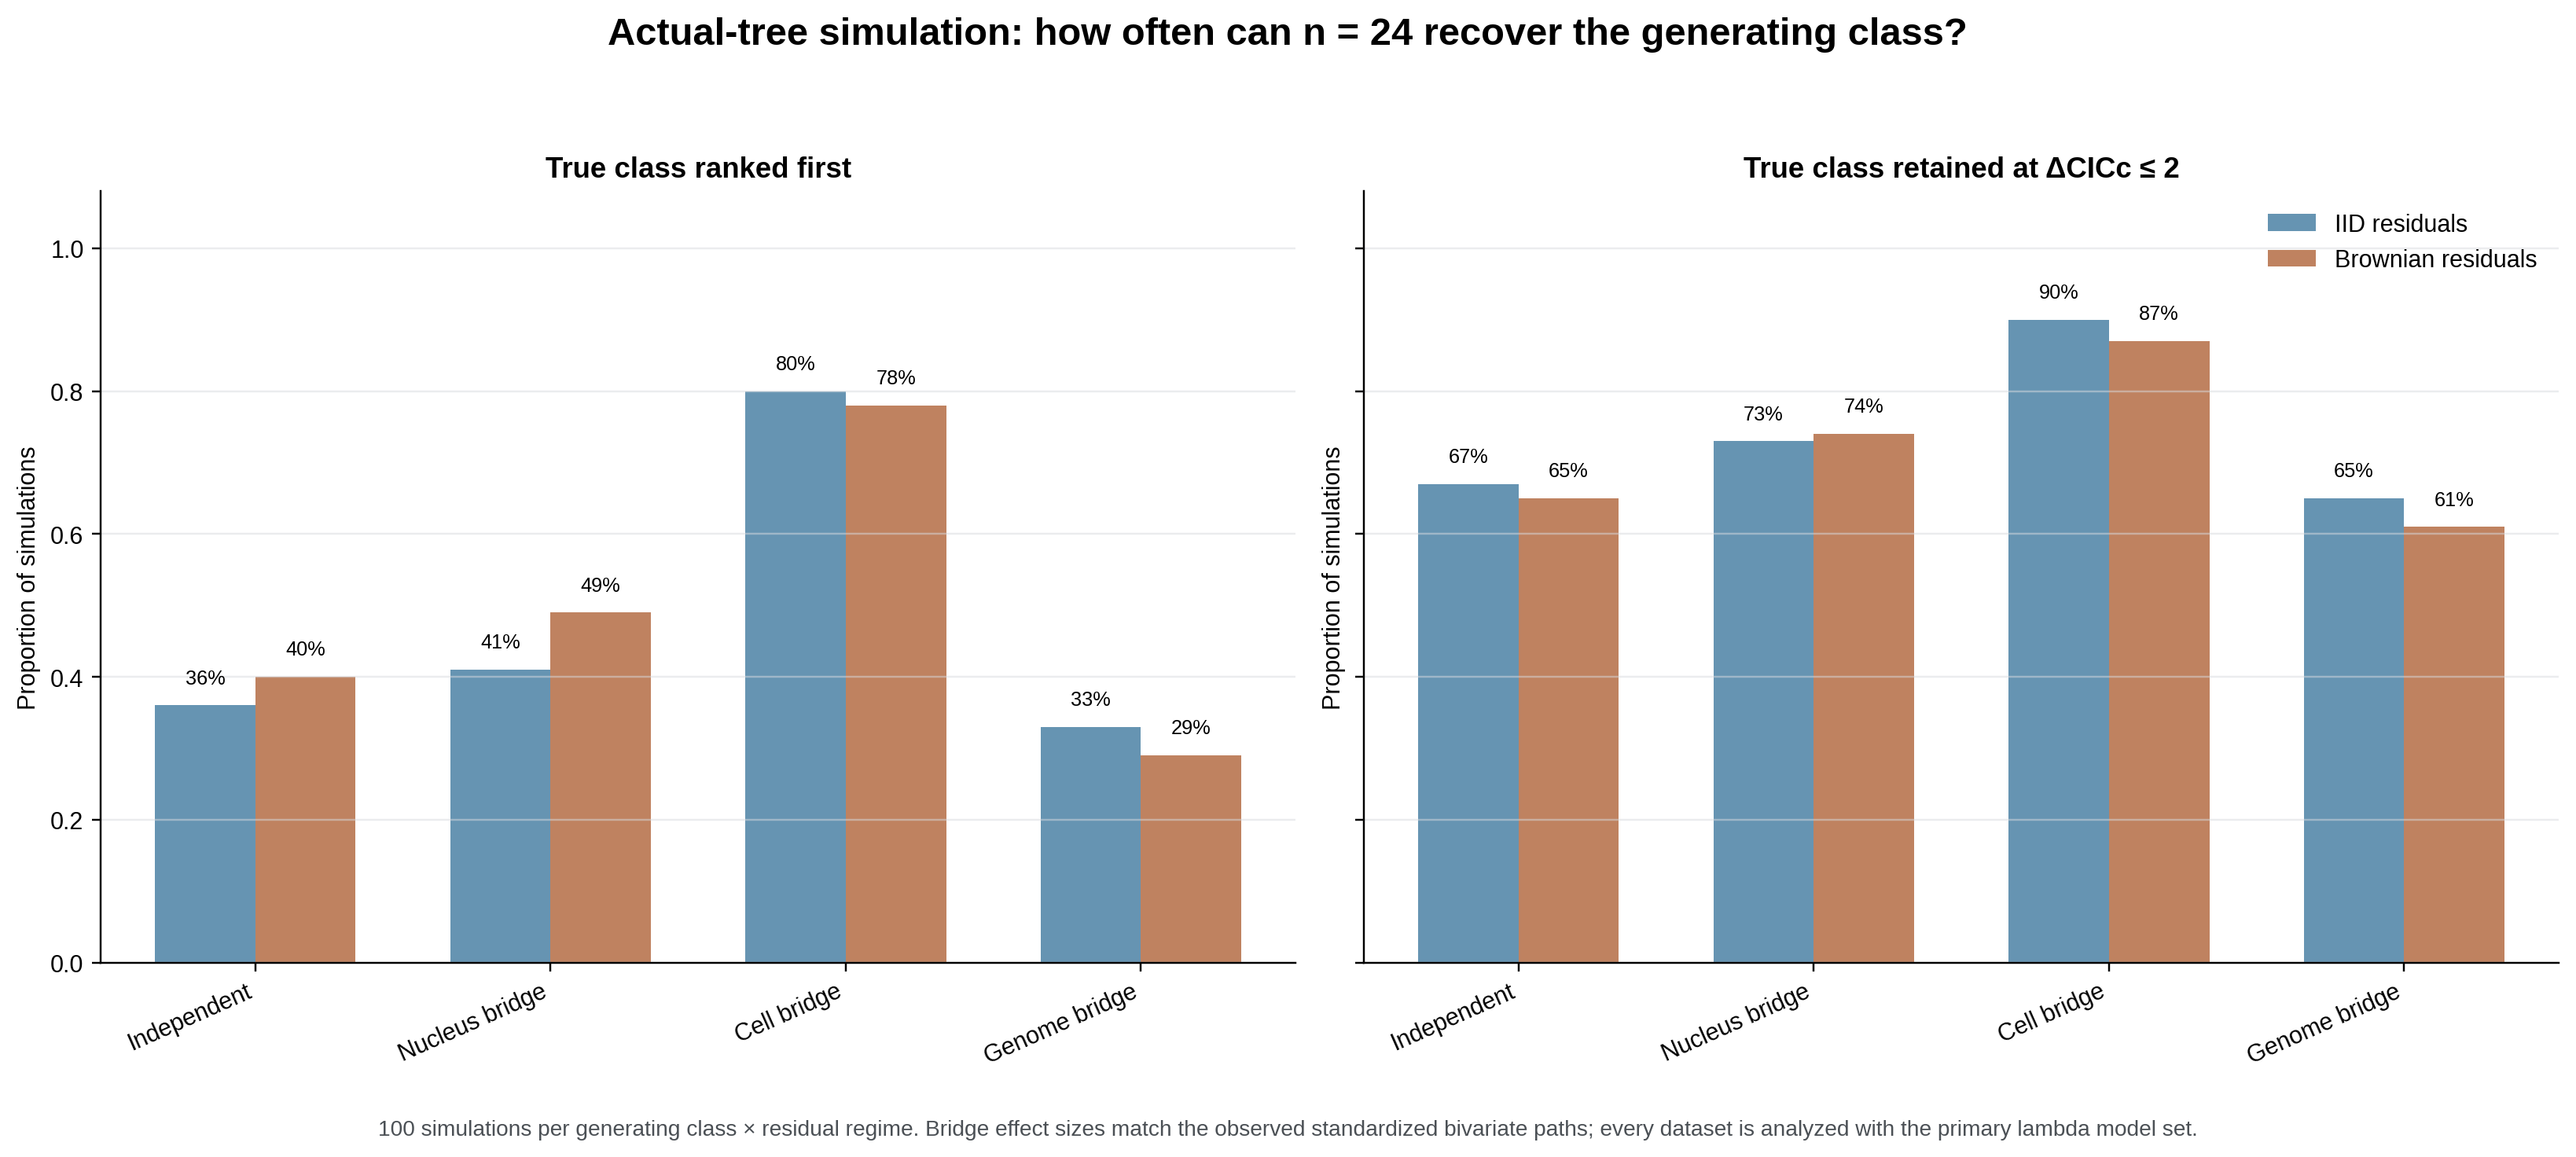

,generating_class,residual_regime,n_simulations,true_class_top_rate,true_class_delta_le_2_rate,true_class_global_fit_rate,unique_true_class_rate,any_bridge_top_rate,median_admissible_competitive_models
0,cell_bridge,brownian,100,78.0%,87.0%,95.0%,58.0%,89.0%,1
1,cell_bridge,iid,100,80.0%,90.0%,97.0%,66.0%,92.0%,1
2,genome_bridge,brownian,100,29.0%,61.0%,96.0%,13.0%,44.0%,2
3,genome_bridge,iid,100,33.0%,65.0%,92.0%,12.0%,50.0%,2
4,independent,brownian,100,40.0%,65.0%,93.0%,5.0%,9.0%,3
5,independent,iid,100,36.0%,67.0%,98.0%,4.0%,6.0%,3
6,nucleus_bridge,brownian,100,49.0%,74.0%,91.0%,29.0%,63.0%,2
7,nucleus_bridge,iid,100,41.0%,73.0%,93.0%,18.0%,59.0%,2


In [11]:
display(Image(filename=str(FIG_DIR / "08_simulation_calibration.png"), width=1300))
display(simulation.style.format({
    "true_class_top_rate": "{:.1%}",
    "true_class_delta_le_2_rate": "{:.1%}",
    "true_class_global_fit_rate": "{:.1%}",
    "unique_true_class_rate": "{:.1%}",
    "any_bridge_top_rate": "{:.1%}",
}))


The simulation uses the actual focal tree, n = 24, observed bridge-sized
coefficients, IID and Brownian residual regimes, and the same ten-class
lambda analysis. It answers whether this study design can reliably recover a
known generating class—not whether any simulated class is biologically true.
There are 100 simulations per generating class and residual regime.
Recovery is imperfect, and retaining several competitive models is common.
That validates a model-uncertainty conclusion rather than a forced winner.


## 8. Biological interpretation and final decision


| Question | Evidence-based answer |
|---|---|
| Are genome, nucleus, and cell size associated? | **Yes.** All three raw and simple lambda-PGLS associations are positive in the finalized 24-species panel. |
| Is a connected bridge structure better than independence? | **Yes.** Independence is globally rejected and has ΔCICc > 15. |
| Which bridge is best supported? | **Cell bridge.** The point estimate ranks it first; Cell collider has ΔCICc = 6.31. |
| Can these data choose genome → nucleus → cell, the reverse chain, or nucleus → both? | **No.** They are Markov-equivalent. |
| Do the effect sizes make biological sense? | **As positive allometric associations, yes.** Larger-genome species tend to have larger nuclei and cells, and nucleus–cell coupling is strongest. Causal direction is not established. |
| What is defensible to report? | A positive three-trait association favoring Cell bridge in this panel, with causal arrow direction explicitly unidentified. |

### Measurement caveat that matters for causality

The genome-size estimate is derived from nuclear integrated optical density;
integrated density includes a nuclear-area component. Therefore the observed
genome–nucleus link is partly coupled by the measurement construction and is
not an independent validation that genome size caused nucleus size. The paired
measurement bootstrap propagates sampling variation but cannot remove that
structural coupling.

### Final verdict

**The analysis resolves association and bridge structure more strongly than
causal direction.** The strongest honest statement is that genome size,
nucleus size, and cell size covary and that Cell bridge is favored in this
finalized panel. None of the Markov-equivalent arrow directions can be selected
from these cross-sectional data alone.


## 9. Reproducibility, failures, and downloadable outputs


In [12]:
display(pd.DataFrame([manifest]).T.rename(columns={0: "value"}))
display(failures)
assert failures.empty

output_files = sorted(
    [path for path in REPORT_DIR.iterdir() if path.is_file()],
    key=lambda path: path.name,
)
display(Markdown("### Report files"))
for path in output_files:
    display(FileLink(path))


,value
analysis_id,cell_nucleus_genome_phylogenetic_path_analysis_v1
generated_at_utc,2026-07-14 19:26:56 UTC
run_scope,full_release
primary_species,24
published_tree_species,18
tested_equivalence_classes,10
labeled_dags,25
markov_equivalence_classes,11
saturated_class_testable,False
primary_evolutionary_model,lambda


,analysis_type,replicate_id,tree_id,evolutionary_model,generating_class,residual_regime,error


### Report files

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/all_three_trait_dags.csv

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/analysis_failures.csv

...

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/simulation_rankings.csv.gz

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/simulation_summary.csv

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/tree_sensitivity_rankings.csv.gz

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/user_mechanism_edges.csv

/home/jake/Projects/Desmognathus_TE/results/data/research_review/cell_nucleus_genome_path/user_mechanism_equivalence_ranking.csv

Statistical engine: `phylopath` 1.3.1 and `phylolm` 2.6.5 in the repository's
Dusky environment. Primary transformations are log10 followed by within-fit
z-scoring. The exact command, package versions, replicate counts, and failure
gate are recorded in `analysis_manifest.json`; hashes of every PNG/PDF path
figure are recorded in `cell_nucleus_genome_path_figure_manifest.json`, and
the executed notebook hash is recorded in `research_review_manifest.json`.
